In [1]:
! pip install opencv-python numpy matplotlib


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import os

print("Libraries Loaded")
print("OpenCV version:", cv2.__version__)

Libraries Loaded
OpenCV version: 4.13.0


In [3]:
def debug_image(name, img):
    
    if img is None:
        print(f"{name} failed to load")
    else:
        print(f"{name} loaded")
        print("Shape:", img.shape)
        print("Type:", img.dtype)
        print()

In [4]:
reference_path = "left.png"
scene_path = "right.png"

reference_img = cv2.imread(reference_path)
scene_img = cv2.imread(scene_path)

debug_image("Reference Image", reference_img)
debug_image("Scene Image", scene_img)

Reference Image loaded
Shape: (315, 408, 3)
Type: uint8

Scene Image loaded
Shape: (325, 405, 3)
Type: uint8



In [5]:
ref_gray = cv2.cvtColor(reference_img, cv2.COLOR_BGR2GRAY)
scene_gray = cv2.cvtColor(scene_img, cv2.COLOR_BGR2GRAY)

print("Converted to grayscale")

Converted to grayscale


In [6]:
orb = cv2.ORB_create(nfeatures=1000)

ref_kp, ref_desc = orb.detectAndCompute(ref_gray, None)
scene_kp, scene_desc = orb.detectAndCompute(scene_gray, None)

print("Reference Features:", len(ref_kp))
print("Scene Features:", len(scene_kp))

Reference Features: 999
Scene Features: 992


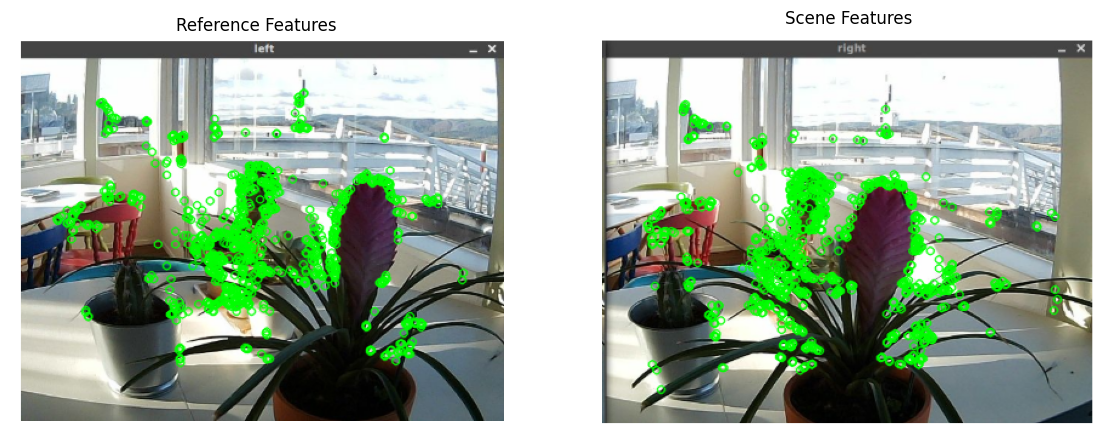

In [7]:
ref_features = cv2.drawKeypoints(reference_img, ref_kp, None, color=(0,255,0))
scene_features = cv2.drawKeypoints(scene_img, scene_kp, None, color=(0,255,0))

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(ref_features, cv2.COLOR_BGR2RGB))
plt.title("Reference Features")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(scene_features, cv2.COLOR_BGR2RGB))
plt.title("Scene Features")
plt.axis("off")

plt.show()

In [8]:
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)

matches = bf.knnMatch(ref_desc, scene_desc, k=2)

print("Total Matches:", len(matches))

Total Matches: 999


In [9]:
good_matches = []

for m,n in matches:
    
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

good_matches = sorted(good_matches, key=lambda x: x.distance)[:50]

print("Good Matches:", len(good_matches))
print("Match Ratio:", len(good_matches)/len(matches))

Good Matches: 50
Match Ratio: 0.05005005005005005


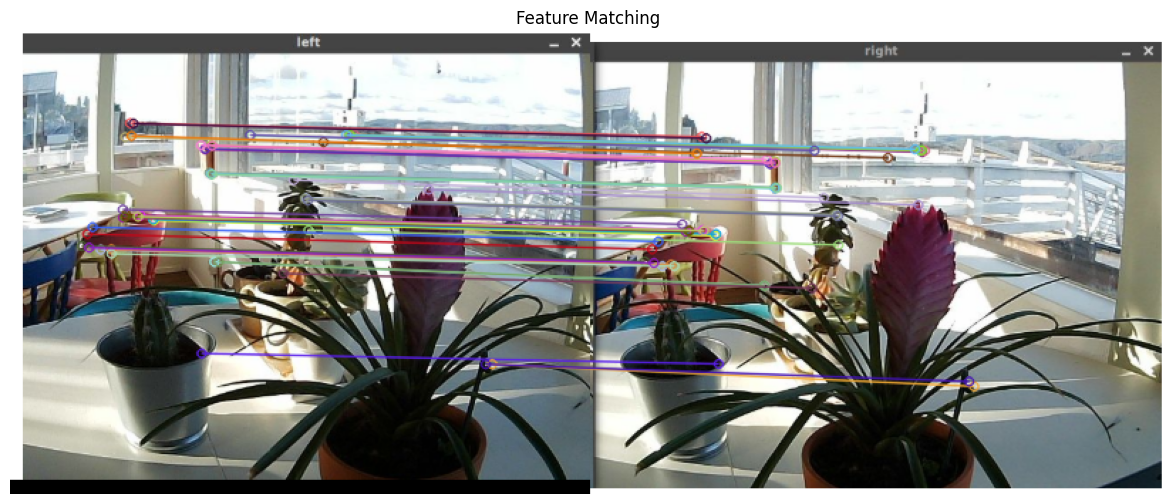

In [10]:
match_img = cv2.drawMatches(
    reference_img, ref_kp,
    scene_img, scene_kp,
    good_matches[:100], None, flags=2
)

plt.figure(figsize=(16,6))
plt.imshow(cv2.cvtColor(match_img, cv2.COLOR_BGR2RGB))
plt.title("Feature Matching")
plt.axis("off")
plt.show()

In [11]:
src_pts = np.float32([ref_kp[m.queryIdx].pt for m in good_matches]).reshape(-1,1,2)
dst_pts = np.float32([scene_kp[m.trainIdx].pt for m in good_matches]).reshape(-1,1,2)

print("Reference Points:", src_pts.shape)
print("Scene Points:", dst_pts.shape)

Reference Points: (50, 1, 2)
Scene Points: (50, 1, 2)


In [12]:
H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

print("Homography Matrix")
print(H)

inliers = np.sum(mask)
outliers = len(mask) - inliers

print("Inliers:", inliers)
print("Outliers:", outliers)

Homography Matrix
[[ 7.46807476e-01 -1.43704150e-01  1.62943351e+01]
 [-4.86444718e-02  7.65236723e-01  2.21741842e+01]
 [-5.94331304e-04 -8.71967935e-04  1.00000000e+00]]
Inliers: 38
Outliers: 12


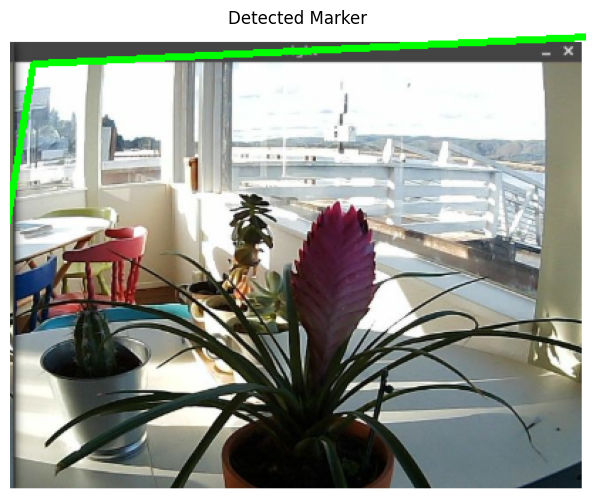

In [13]:
h, w = reference_img.shape[:2]

corners = np.float32([[0,0],[w,0],[w,h],[0,h]]).reshape(-1,1,2)

transformed = cv2.perspectiveTransform(corners, H)

scene_marker = scene_img.copy()

cv2.polylines(scene_marker, [np.int32(transformed)], True, (0,255,0),3)

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(scene_marker, cv2.COLOR_BGR2RGB))
plt.title("Detected Marker")
plt.axis("off")
plt.show()

In [14]:
def project_cube(H, size):

    cube = np.float32([
        [0,0,0],[size,0,0],[size,size,0],[0,size,0],
        [0,0,-size],[size,0,-size],[size,size,-size],[0,size,-size]
    ])

    pts = []

    for p in cube:
        
        homo = np.array([p[0], p[1], 1])
        proj = H @ homo
        proj = proj[:2] / proj[2]
        
        pts.append(proj)

    return np.array(pts)

In [15]:
def draw_cube(img, corners):

    edges = [
        (0,1),(1,2),(2,3),(3,0),
        (4,5),(5,6),(6,7),(7,4),
        (0,4),(1,5),(2,6),(3,7)
    ]

    for s,e in edges:
        pt1 = tuple(map(int,corners[s]))
        pt2 = tuple(map(int,corners[e]))
        cv2.line(img, pt1, pt2, (255,0,255),3)

    return img

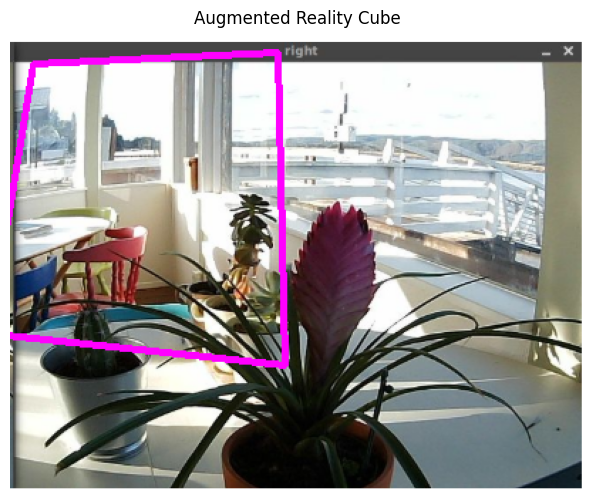

In [16]:
cube_corners = project_cube(H, 200)

ar_img = scene_img.copy()

ar_img = draw_cube(ar_img, cube_corners)

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(ar_img, cv2.COLOR_BGR2RGB))
plt.title("Augmented Reality Cube")
plt.axis("off")
plt.show()

In [17]:
cv2.imwrite("feature_matches.png", match_img)
cv2.imwrite("marker_detection.png", scene_marker)
cv2.imwrite("ar_cube.png", ar_img)

print("Saved Results")

Saved Results
